In [25]:
# Cell 1 — setup (keep autoreload at top of every notebook)
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import fetch_data, compute_features

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# Cell 2 — reload the data you already downloaded
# We re-fetch here so each notebook is self-contained
prices = fetch_data()
features = compute_features(prices)
print(f"Features shape: {features.shape}")
print(f"Date range: {features.index[0].date()} to {features.index[-1].date()}")

[*********************100%***********************]  4 of 4 completed

Features shape: (3753, 16)
Date range: 2010-02-02 to 2024-12-30


In [27]:
# Cell 3 — prepare data for the model
# Neural networks expect plain numbers, not pandas DataFrames,
# and they work best when all features are on a similar scale.
# StandardScaler transforms each column to have mean=0, std=1.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features.values)        # numpy array, scaled
X_tensor = torch.tensor(X, dtype=torch.float32) # convert to PyTorch tensor

print(f"Input shape: {X_tensor.shape}")
# Should be ~(3400, 16) — about 3400 trading days, 16 features

Input shape: torch.Size([3753, 16])


In [28]:
# Cell 3b — clip extreme outliers before fitting the HMM
# HMMs are sensitive to extreme values. We clip each feature at the
# 1st and 99th percentile — so the most extreme 1% of values on each
# end get pulled in to a reasonable range. This doesn't lose meaningful
# information, it just prevents numerical blowups during training.

import numpy as np
from sklearn.preprocessing import StandardScaler

# Clip outliers in the raw feature matrix
lower = np.percentile(features.values, 1, axis=0)
upper = np.percentile(features.values, 99, axis=0)
clipped = np.clip(features.values, lower, upper)

# Re-scale after clipping
scaler = StandardScaler()
X = scaler.fit_transform(clipped)

# Sanity check — max absolute value should be reasonable now (under ~4)
print(f"Max absolute value after clipping: {np.abs(X).max():.2f}")
print(f"Any NaNs: {np.isnan(X).any()}")
print(f"Any Infs: {np.isinf(X).any()}")

Max absolute value after clipping: 4.35
Any NaNs: False
Any Infs: False


In [29]:
# Cell 4 — fit a Hidden Markov Model for regime detection
# An HMM assumes the data was generated by a hidden state (the regime)
# that you can't observe directly. It learns:
#   - emission probabilities: what does each regime's data look like?
#   - transition probabilities: how likely is it to switch regimes?
# The transition matrix is what gives us persistent, sticky regimes.

from hmmlearn.hmm import GaussianHMM

N_REGIMES = 3

hmm = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type="full",   # each regime gets its own covariance matrix
    n_iter=100,               # number of training iterations
    random_state=42           # for reproducibility
)

hmm.fit(X)   # X is the scaled numpy array from Cell 3, not a tensor

print("HMM trained.")
print(f"\nTransition matrix (rows = from regime, cols = to regime):")
print(hmm.transmat_.round(3))
# Each row should sum to 1.0
# High diagonal values (e.g. 0.97) mean the model is sticky — good

/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/si

HMM trained.

Transition matrix (rows = from regime, cols = to regime):
[[0.974 0.021 0.005]
 [0.011 0.957 0.032]
 [0.005 0.019 0.977]]


In [30]:
# Cell 5 — extract regime labels
regime_labels = hmm.predict(X)

unique, counts = np.unique(regime_labels, return_counts=True)
for regime, count in zip(unique, counts):
    print(f"Regime {regime}: {count} days ({count/len(regime_labels)*100:.1f}%)")

Regime 0: 810 days (21.6%)
Regime 1: 1168 days (31.1%)
Regime 2: 1775 days (47.3%)


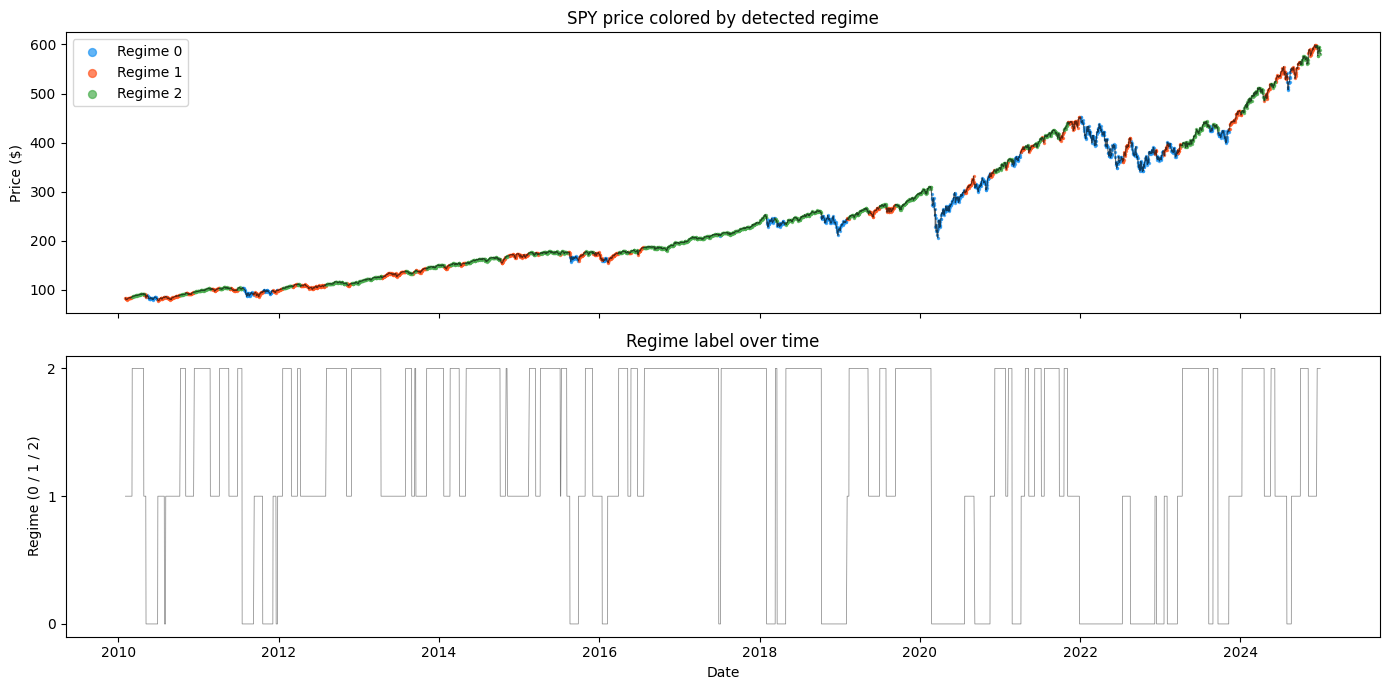

Saved to outputs/regime_labels.png


In [31]:
# Cell 6 — the key plot: regimes overlaid on SPY price
# This is your first "does it make sense?" sanity check.
# Good sign: regime changes should roughly align with major market events.
spy_prices = prices["SPY"].loc[features.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top panel: SPY price colored by regime
colors = ["#2196F3", "#FF5722", "#4CAF50"]  # blue, orange, green
labels = ["Regime 0", "Regime 1", "Regime 2"]

axes[0].plot(spy_prices.index, spy_prices.values, color="black", linewidth=0.8, alpha=0.6)
for regime in range(N_REGIMES):
    mask = regime_labels == regime
    dates = spy_prices.index[mask]
    vals  = spy_prices.values[mask]
    axes[0].scatter(dates, vals, s=2, color=colors[regime], label=labels[regime], alpha=0.7)

axes[0].set_title("SPY price colored by detected regime")
axes[0].set_ylabel("Price ($)")
axes[0].legend(markerscale=4)

# Bottom panel: regime label over time as a line
axes[1].plot(spy_prices.index, regime_labels, linewidth=0.5, color="gray")
axes[1].set_title("Regime label over time")
axes[1].set_ylabel("Regime (0 / 1 / 2)")
axes[1].set_yticks([0, 1, 2])
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../outputs/regime_labels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/regime_labels.png")

In [32]:
# Cell 7 — save the HMM and regime labels so other notebooks can use them
import pickle

# Save the trained HMM model
with open("../models/hmm_regime_detector.pkl", "wb") as f:
    pickle.dump(hmm, f)

# Save the regime labels alongside the dates as a CSV
regime_df = pd.DataFrame({
    "date": features.index,
    "regime": regime_labels
}).set_index("date")

regime_df.to_csv("../data/processed/regime_labels.csv")

print("Saved HMM model and regime labels.")
print(regime_df.value_counts("regime"))

Saved HMM model and regime labels.
regime
2    1775
1    1168
0     810
Name: count, dtype: int64
